<a href="https://colab.research.google.com/github/Jayesh-naik/Plant-Disease-Detection/blob/main/TPlant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: Mounting the drive and creating the Required folders


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# PROJECT_DIR = '/content/drive/MyDrive/IPD'
# DATASET_DIR = os.path.join(PROJECT_DIR, 'Dataset')
# MODEL_DIR = os.path.join(PROJECT_DIR, 'saved_model')
# RESULTS_DIR = os.path.join(PROJECT_DIR,'results')

# os.makedirs(PROJECT_DIR, exist_ok=True)
# os.makedirs(DATASET_DIR, exist_ok=True)
# os.makedirs(MODEL_DIR, exist_ok=True)
# os.makedirs(RESULTS_DIR,exist_ok = True)



MessageError: Error: credential propagation was unsuccessful

STEP 2: Importing the required libraries


In [ ]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import json
import time

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  print("GPU is available")
else:
  print("GPU not available")


GPU not available


STEP 3: Setting Hyperparameters

In [ ]:
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE,IMG_SIZE,3)

BATCH_SIZE = 16
EPOCHS = 20
FINE_TUNE_EPOCHS = 10
LEARNING_RATE = 1e-4

CLASS_NAMES = ['Early_Blight','Healthy','Late_Blight']
NUM_CLASSES = len(CLASS_NAMES)

TRAIN_DIR    = os.path.join(DATASET_DIR, 'Training')
VALIDATE_DIR = os.path.join(DATASET_DIR, 'Validation')
TEST_DIR     = os.path.join(DATASET_DIR, 'Testing')

MODEL_PATH = os.path.join(MODEL_DIR,'IPD_teacher_efficientnetb3.keras')
CLASS_NAMES_PATH = os.path.join(MODEL_DIR,'class_names.json')




STEP 4:Explore the Dataset

In [ ]:
def count_images(folder_path):
  all_files = os.listdir(folder_path);
  image_files = [ f for f in all_files
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
  return len(image_files)

for split_name , split_path in [('Train',TRAIN_DIR),('Validate',VALIDATE_DIR),('Test',TEST_DIR)]:
  print(f"{split_name} set - {split_path}")

  if not os.path.exists(split_path):
    print(f"Directory {split_path} does not exist")
    continue

  split_total = 0

  for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path,class_name)

    if os.path.isdir(class_path):
      count = count_images(class_path)
      split_total += count
      print(f"{class_name} : {count} images")

  print(f"Total images : {split_total} images")
  print(f" {'_'*40}")

print("Balance check on training set : ")

train_counts = []
for class_name in CLASS_NAMES:
  class_path = os.path.join(TRAIN_DIR,class_name)
  if os.path.exists(class_path):
    train_counts.append(count_images(class_path))

if train_counts :
  biggest = max(train_counts)
  smallest = min(train_counts)

  if smallest == 0:
    print("One class folder doesn't exist")
  else :
    ratio = biggest / smallest
    if ratio < 2 :
      print("Dataset is balanced")
    else :
      print("Dataset is imbalanced")



Train set - /content/drive/MyDrive/IPD/Dataset/Training
Early_Blight : 1303 images
Healthy : 816 images
Late_Blight : 1132 images
Total images : 3251 images
 ________________________________________
Validate set - /content/drive/MyDrive/IPD/Dataset/Validation
Early_Blight : 163 images
Healthy : 103 images
Late_Blight : 151 images
Total images : 417 images
 ________________________________________
Test set - /content/drive/MyDrive/IPD/Dataset/Testing
Early_Blight : 162 images
Healthy : 102 images
Late_Blight : 141 images
Total images : 405 images
 ________________________________________
Balance check on training set : 
Dataset is balanced


STEP 5 : Load and Prepare the images(Data Generators)

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 20,
    horizontal_flip = True,
    zoom_range = 0.15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    brightness_range = [0.8,1.2],
    fill_mode = 'nearest'
)

val_datagen  = ImageDataGenerator(preprocessing_function = preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True,
    seed = 42
)

val_data = val_datagen.flow_from_directory(
    VALIDATE_DIR,
    target_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

class_indices = train_data.class_indices
idx_to_class = {v : k for k,v in class_indices.items()}


Found 3251 images belonging to 3 classes.
Found 417 images belonging to 3 classes.
Found 405 images belonging to 3 classes.


STEP 6 : Looking at some sample images

In [ ]:
images , labels = next(train_data)

fig , axes = plt.subplots(3,3,figsize=(10,10))
fig.suptitle("Sample Training Images",fontsize=16,fontweight='bold')

title_colour = {
    'Early_Blight' : 'red',
    'Healthy' : 'green',
    'Late_Blight' : 'purple'
}

for i , ax in enumerate(axes.flatten()):
  ax.imshow(images[i])

  class_number = np.argmax(labels[i])
  class_name = idx_to_class[class_number]

  ax.set_title(class_name,color=title_colour.get(class_name,'black'),
               fontsize=11,fontweight='bold')
  ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,'sample_images.png'),dpi=100,bbox_inches = 'tight')
plt.show()


STEP 7 : Build the model

In [ ]:
base_model = EfficientNetB3(
    include_top = False,
    weights = 'imagenet',
    input_shape = IMG_SHAPE,
    pooling = 'avg'
)

base_model.trainable = False
print(f"EfficientNetB3 loaded.Total layers : {len(base_model.layers)} (all frozen)")

inputs = keras.Input(shape = IMG_SHAPE)

x = base_model(inputs,training = False)

x = layers.Dense(128,activation='relu')(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES,activation='softmax')(x)

model = Model(inputs = inputs,outputs = outputs,name='IPD_Teacher')

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = LEARNING_RATE),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

print("model built! Here's the summary : ")
model.summary()

total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Out of {total_params:,} total parameters : ")
print(f"{trainable_params:,} are Trainable <- Dense + Output layers")
print(f"{total_params-trainable_params:,} are Frozen")



EfficientNetB3 loaded.Total layers : 386 (all frozen)
model built! Here's the summary : 


Model: "IPD_Teacher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,980,658 (41.89 MB)

 Trainable params: 197,123 (770.01 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

Out of 10,980,658 total parameters : 
197,123 are Trainable <- Dense + Output layers
10,783,535 are Frozen


STEP 8 : Set up safety nets(callbacks)

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath = MODEL_PATH,
    monitor = 'val_accuracy',
    save_best_only = True,
    mode = 'max',
    verbose = 1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor = 'val_accuracy',
    patience = 5,
    restore_best_weights = True,
    verbose = 1
)

my_callbacks = [checkpoint,early_stop]

print(f"ModelCheckpoint will automatically save best model to : {MODEL_PATH}")
print(f"EarlyStopping will stop training after 5 epochs with no improvement")

ModelCheckpoint will automatically save best model to : /content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras
EarlyStopping will stop training after 5 epochs with no improvement


Step 9 : Train the model

In [ ]:
start_time = time.time()

history_stage1 = model.fit(
    train_data,
    validation_data = val_data,
    epochs = EPOCHS,
    callbacks = my_callbacks,
    verbose = 1
)

minutes_taken = (time.time() - start_time)/60
print(f"Training completed in {minutes_taken:.2f} minutes")
print(f"Best Validation Accuracy : {max(history_stage1.history['val_accuracy'])*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.6168 - loss: 0.8522
Epoch 1: val_accuracy improved from -inf to 0.89448, saving model to /content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 130s 459ms/step - accuracy: 0.6174 - loss: 0.8512 - val_accuracy: 0.8945 - val_loss: 0.3822
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8844 - loss: 0.3434
Epoch 2: val_accuracy improved from 0.89448 to 0.94484, saving model to /content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 64s 313ms/step - accuracy: 0.8845 - loss: 0.3432 - val_accuracy: 0.9448 - val_loss: 0.2322
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.9171 - loss: 0.2522
Epoch 3: val_accuracy improved from 0.94484 to 0.95923, saving model to /content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 63s 306ms/step - accuracy: 0.9172 - l

STEP 10 : Fine - tune the model

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
  layer.trainable = False

unfrozen = sum(1 for layer in base_model.layers if layer.trainable)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-5),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

checkpoint_s2 = keras.callbacks.ModelCheckpoint(
    filepath = MODEL_PATH,
    monitor = 'val_accuracy',
    save_best_only = True,
    mode = 'max',
    verbose = 1
)

early_stop_s2 = keras.callbacks.EarlyStopping(
    monitor = 'val_accuracy',
    patience = 5,
    restore_best_weights = True,
    verbose = 1
)

start_time = time.time()

history_stage2 = model.fit(
    train_data,
    validation_data = val_data,
    epochs = FINE_TUNE_EPOCHS,
    callbacks = [checkpoint_s2,early_stop_s2],
    verbose = 1
)

minutes_taken = (time.time() - start_time)/60
print(f"Training completed in {minutes_taken:.2f} minutes")
print(f"Best Validation Accuracy : {max(history_stage1.history['val_accuracy'])*100:.2f}%")

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8891 - loss: 0.3663
Epoch 1: val_accuracy improved from -inf to 0.96643, saving model to /content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 147s 505ms/step - accuracy: 0.8891 - loss: 0.3660 - val_accuracy: 0.9664 - val_loss: 0.1405
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9336 - loss: 0.2315
Epoch 2: val_accuracy improved from 0.96643 to 0.97362, saving model to /content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 65s 317ms/step - accuracy: 0.9336 - loss: 0.2314 - val_accuracy: 0.9736 - val_loss: 0.1248
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9405 - loss: 0.1814
Epoch 3: val_accuracy improved from 0.97362 to 0.97842, saving model to /content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 69s 339ms/step - accuracy: 0.9405 - l

STEP 11 : Plot the Training Curves

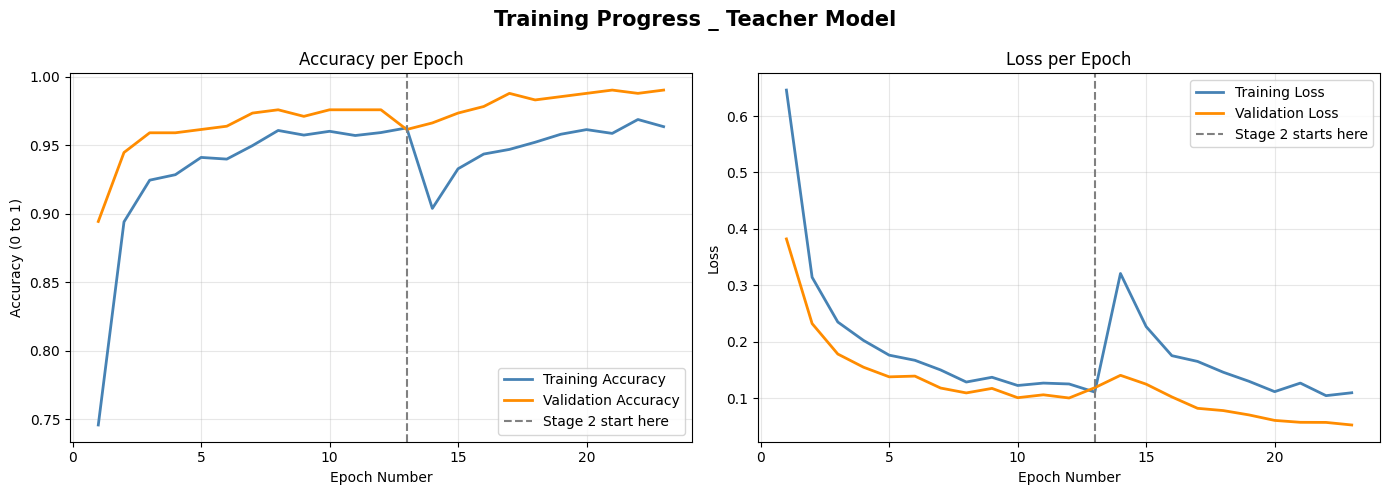

Training curves saved to: /content/drive/MyDrive/IPD/results/training_history.png


In [ ]:
all_train_acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
all_val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
all_train_loss = history_stage1.history['loss'] + history_stage2.history['loss']
all_val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

total_epochs_run = len(all_train_acc)
stage1_epochs_run = len(history_stage1.history['accuracy'])
epoch_numbers = range(1 , total_epochs_run + 1)

fig , (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Training Progress _ Teacher Model',fontsize = 15,fontweight='bold')

ax1.plot(epoch_numbers,all_train_acc,color='steelblue',label='Training Accuracy',linewidth = 2)
ax1.plot(epoch_numbers, all_val_acc,   color='darkorange', label='Validation Accuracy', linewidth=2)

ax1.axvline(x = stage1_epochs_run,color = 'grey',linestyle='--',label='Stage 2 start here')
ax1.set_title('Accuracy per Epoch')
ax1.set_xlabel('Epoch Number')
ax1.set_ylabel('Accuracy (0 to 1)')
ax1.legend()
ax1.grid(True,alpha=0.3)

ax2.plot(epoch_numbers, all_train_loss, color='steelblue',  label='Training Loss',   linewidth=2)
ax2.plot(epoch_numbers, all_val_loss,   color='darkorange', label='Validation Loss', linewidth=2)
ax2.axvline(x=stage1_epochs_run, color='grey', linestyle='--', label='Stage 2 starts here')
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epoch Number')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_save_path = os.path.join(RESULTS_DIR,'training_history.png')
plt.savefig(plot_save_path,dpi=150,bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {plot_save_path}")


STEP 12 : Test the model on unseen data

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 185s 7s/step - accuracy: 0.9787 - loss: 0.1126

 Test Accuracy : 98.77%
 Test Loss     : 0.0720
26/26 ━━━━━━━━━━━━━━━━━━━━ 32s 616ms/step
Full classification report : 
              precision    recall  f1-score   support

Early_Blight       1.00      0.99      0.99       162
     Healthy       0.96      0.99      0.98       102
 Late_Blight       0.99      0.99      0.99       141

    accuracy                           0.99       405
   macro avg       0.98      0.99      0.99       405
weighted avg       0.99      0.99      0.99       405

✅ Report saved to: /content/drive/MyDrive/IPD/results/classification_report.txt


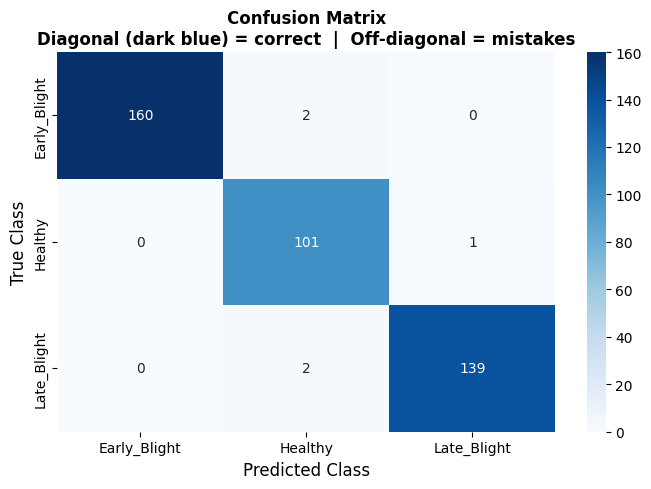

Confusion matrix saved to: /content/drive/MyDrive/IPD/results/confusion_matrix.png


In [ ]:
best_model = keras.models.load_model(MODEL_PATH)

test_loss, test_acc = best_model.evaluate(test_data,verbose = 1)
print(f"\n Test Accuracy : {test_acc * 100:.2f}%")
print(f" Test Loss     : {test_loss:.4f}")

test_data.reset()
all_predictions = best_model.predict(test_data,verbose = 1)
predicted_classes = np.argmax(all_predictions,axis = 1)
true_classes = test_data.classes

print("Full classification report : ")

report = classification_report(true_classes,predicted_classes,target_names=CLASS_NAMES)
print(report)

report_path = os.path.join(RESULTS_DIR,'classification_report.txt')
with open(report_path,'w') as f:
  f.write(f"Teacher Model - Test Results\n")
  f.write(f"Test Accuracy : {test_acc * 100:.2f}%\n\n")
  f.write(report)
print(f"✅ Report saved to: {report_path}")

cm = confusion_matrix(true_classes,predicted_classes)

fig, ax = plt.subplots(figsize = (7,5))
sns.heatmap(
    cm,
    annot       = True,          # Write the number inside each box
    fmt         = 'd',           # Format numbers as plain integers (not 1.0e+02)
    cmap        = 'Blues',       # Blue colour scale (darker = more images)
    xticklabels = CLASS_NAMES,   # Column labels = predicted class names
    yticklabels = CLASS_NAMES    # Row labels    = true class names
)

ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class',      fontsize=12)
ax.set_title('Confusion Matrix\n'
             'Diagonal (dark blue) = correct  |  Off-diagonal = mistakes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Confusion matrix saved to: {cm_path}")

# Store test_accuracy for the final summary cell
test_accuracy = test_acc


STEP 13 : Save class names and write summary file

In [ ]:
print(f" Model already saved at (by ModelCheckpoint during training):")
print(f"   {MODEL_PATH}")

idx_to_name_clean = {
    '0': 'Early_Blight',
    '1': 'Healthy',
    '2': 'Late_Blight'
}

with open(CLASS_NAMES_PATH, 'w') as f:
    json.dump(idx_to_name_clean, f, indent=2)

print(f"Class names saved to: {CLASS_NAMES_PATH}")
print(f"contents : {idx_to_class}")

summary_path = os.path.join(RESULTS_DIR, 'model_summary.txt')

with open(summary_path, 'w') as f:
    f.write("IPD Teacher Model — Training Summary\n")
    f.write("\n\n")
    f.write(f"Architecture  : EfficientNetB3 (Transfer Learning)\n")
    f.write(f"Classes       : {CLASS_NAMES}\n")
    f.write(f"Image size    : {IMG_SIZE}x{IMG_SIZE} pixels\n")
    f.write(f"Batch size    : {BATCH_SIZE}\n")
    f.write(f"Test Accuracy : {test_accuracy*100:.2f}%\n")
    f.write("-" * 40 + "\n")
    f.write(f"Model saved   : {MODEL_PATH}\n")
    f.write(f"Classes saved : {CLASS_NAMES_PATH}\n")
    f.write(f"Results saved : {RESULTS_DIR}\n")

print(f"Summary saved to: {summary_path}")

 Model already saved at (by ModelCheckpoint during training):
   /content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras
Class names saved to: /content/drive/MyDrive/IPD/saved_model/class_names.json
contents : {0: 'Early_Blight', 1: 'Healthy', 2: 'Late_Blight', '0': 'Early_Blight', '1': 'Healthy', '2': 'Late_Blight'}
Summary saved to: /content/drive/MyDrive/IPD/results/model_summary.txt


STEP 14 : Testing an image

In [ ]:
import numpy as np
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from google.colab import files
import PIL.Image

####################
MODEL_PATH = '/content/drive/MyDrive/IPD/saved_model/IPD_teacher_efficientnetb3.keras'
CLASS_NAMES_PATH = '/content/drive/MyDrive/IPD/saved_model/class_names.json'
IMG_SIZE = 224
####################

prediction_model = keras.models.load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, 'r') as f:
    idx_to_name = json.load(f)

print("Please select a tomato leaf image from your computer...")
uploaded_files = files.upload()

for fn in uploaded_files.keys():
  print(f"\nProcessing : {fn} . . . ")

  img = PIL.Image.open(fn).convert('RGB')
  img_resized = img.resize((IMG_SIZE,IMG_SIZE))
  img_array = np.array(img_resized,dtype=np.float32)
  img_array = preprocess_input(img_array)
  img_array = np.expand_dims(img_array,axis = 0)

  probabilities = prediction_model.predict(img_array,verbose = 0)
  probabilities = probabilities[0]

  predicted_index = np.argmax(probabilities)
  predicted_class = idx_to_name[str(predicted_index)]
  confidence = probabilities[predicted_index] * 100

  print("=" * 45)
  print(f"RESULT : {predicted_class.replace('_',' ')}")
  print(f"Confidence : {confidence:.2f}%")
  print("=" * 45)

  print("\n All class probabities : ")
  for i in range(len(probabilities)):
    class_name = idx_to_name[str(i)]
    probability = probabilities[i] * 100
    print(f"    {class_name.replace('_',' ')} : {probability:.2f}%")

print("\nPrediction Done!")


Please select a tomato leaf image from your computer...


Saving test_late_blight.jpg to test_late_blight (1).jpg
Saving test_early_blight.jpg to test_early_blight.jpg

Processing : test_late_blight (1).jpg . . . 
RESULT : Late Blight
Confidence : 96.24%

 All class probabities : 
    Early Blight : 2.06%
    Healthy : 1.70%
    Late Blight : 96.24%

Processing : test_early_blight.jpg . . . 
RESULT : Late Blight
Confidence : 99.94%

 All class probabities : 
    Early Blight : 0.02%
    Healthy : 0.03%
    Late Blight : 99.94%

Prediction Done!
